## 1. EDA

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv("data/Mall_Customers.csv")

In [22]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [23]:
df.shape

(200, 5)

In [24]:
df.dtypes

CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

plan for preprocessing: drop ID, encode gender, and scale numerical values.

In [25]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [26]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

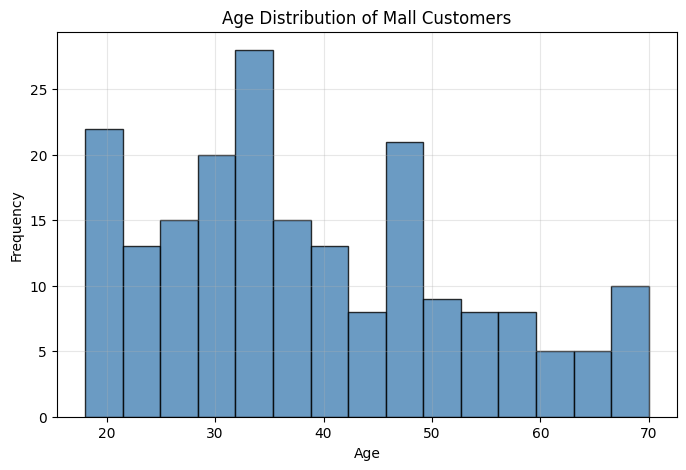

In [29]:
plt.figure(figsize=(8, 5))
plt.hist(df['Age'], bins=15, color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution of Mall Customers')
plt.grid(axis='both', alpha=0.3)
plt.show()

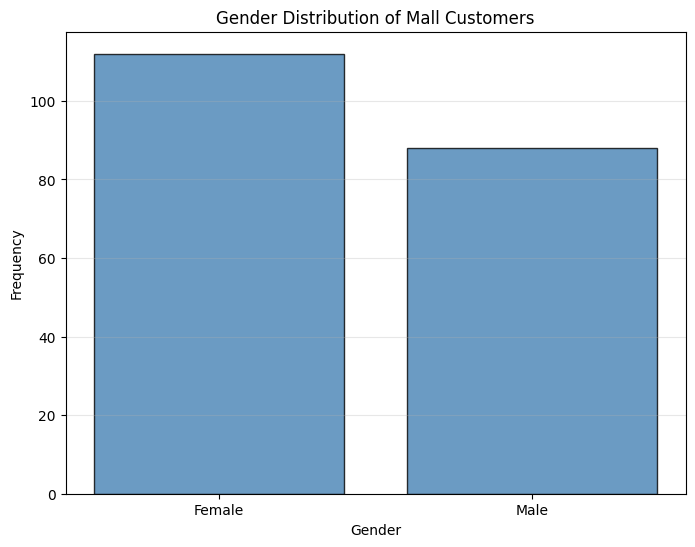

In [30]:
plt.figure(figsize=(8, 6))
plt.bar(df['Gender'].value_counts().index,df["Gender"].value_counts().values, color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.title('Gender Distribution of Mall Customers')
plt.grid(axis='y', alpha=0.3)
plt.show()

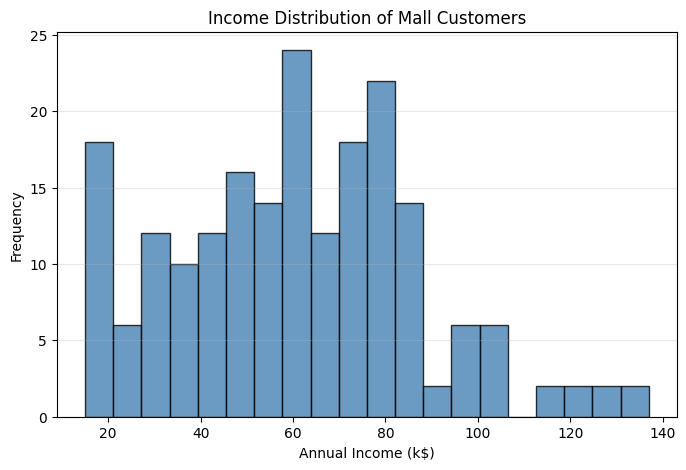

In [31]:
plt.figure(figsize=(8, 5))
plt.hist(df['Annual Income (k$)'], bins=20, color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Frequency')
plt.title('Income Distribution of Mall Customers')
plt.grid(axis='y', alpha=0.3)
plt.show()

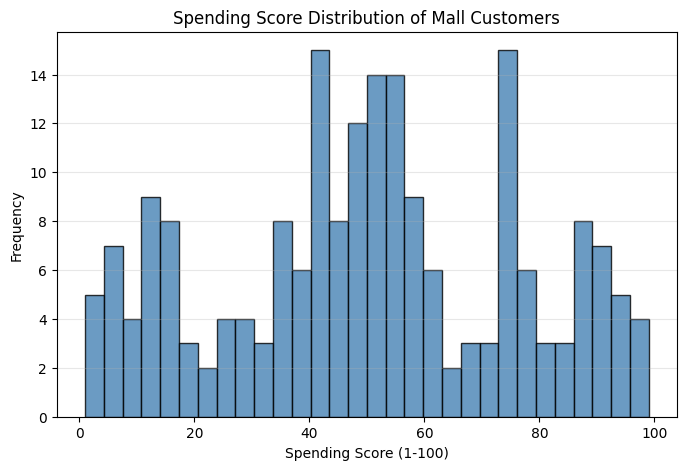

In [32]:
plt.figure(figsize=(8, 5))
plt.hist(df['Spending Score (1-100)'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Frequency')
plt.title('Spending Score Distribution of Mall Customers')
plt.grid(axis='y', alpha=0.3)
plt.show()

## Preprocessing

In [33]:
from sklearn.preprocessing import StandardScaler

In [34]:
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

Feature selection

CustomerID was dropped. It's an arbitrary identifier with no relationship to behavior, and including it would just add noise to distance calculations.

Gender was dropped. EDA showed no meaningful difference in Income or Spending Score across genders. Segments here are defined by actual behavior: Age, Income, Spending.

Why scaling matters

KMeans clusters based on distance. Features with larger numeric ranges (Income: 15–140) dominate over smaller-range features (Age: 18–70) purely due to scale, not actual importance. StandardScaler puts all features on equal footing (mean 0, std 1) so each contributes fairly to clustering.

## Finding K

In [35]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    silhouette_scores.append(score)

best_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(best_k)

6


Finding the best k

The elbow method alone is subjective, there's no single objective rule for where the "bend" is. Silhouette score was used instead: for each k from 2 to 10, KMeans was fit and the average silhouette score computed. k=6 gave the highest score (0.43).

A silhouette plot at k=6 confirmed the result: all 6 clusters sit mostly to the right of the average line, cluster sizes are reasonably balanced, and only a tiny sliver of one cluster dips below zero.

k=5 was also tested as a sanity check. The resulting scatter plot was harder to interpret, with less clean separation between groups. k=6 was kept as final.

## Model

In [36]:
final_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = final_model.fit_predict(scaled_features)

In [37]:
df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,56.333333,54.266667,49.066667
1,26.794872,57.102564,48.128205
2,41.939394,88.939394,16.969697
3,32.692308,86.538462,82.128205
4,25.000000,25.260870,77.608696
5,45.523810,26.285714,19.380952


Cluster profiles

Cluster 0: older, average income, average spending
Cluster 1: young, average income, average spending
Cluster 2: high income, low spending. Careful with money
Cluster 3: high income, high spending. Prime target segment
Cluster 4: low income, high spending. Likely credit-reliant
Cluster 5: low income, low spending. Budget-conscious

Clusters 0 and 1 have nearly identical income and spending but a 30-year age gap. In 2D clustering (income and spending only) these two would merge into one cluster. Adding age split them into two segments that look the same on paper but are a generation apart.

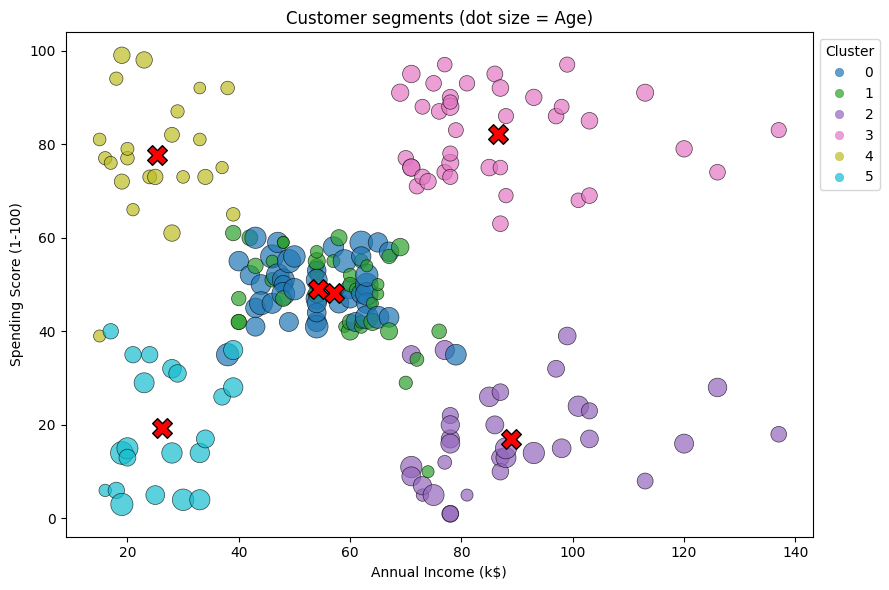

In [38]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='tab10',
    s=df['Age'] * 4,
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

centers = scaler.inverse_transform(final_model.cluster_centers_)
plt.scatter(
    centers[:, 1], centers[:, 2],   # income, spending columns.
    c='red', marker='X', s=200, label='Centroids', edgecolors='black'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer segments (dot size = Age)')
plt.legend(*scatter.legend_elements(), title="Cluster", loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

Visualizing the clusters

Income and Spending Score are plotted directly, since those are the two axes that separate clusters most clearly. Age is encoded as dot size, since a third feature can't get its own axis on a 2D plot. Red X markers are the cluster centroids, inverse-transformed back to the original scale since the model was fit on scaled data.

The plot confirms the profile table: cluster 3 (pink) and cluster 4 (yellow) are visibly smaller dots, matching their younger average age, while cluster 2 (purple) and cluster 5 (cyan) skew toward larger, older dots.